### Multinomial Naive Bayes for Text Classification

Naive Bayes classifiers are a group of extremely fast and simple classification algorithms that are often suitable for very high-dimensional datasets. This notebook demonstrates how to classify text documents into categories.

**1. Fundamental Concept**

In text classification, we use the Multinomial distribution. The model assumes that the features (word counts) are generated from a multinomial distribution for each category.

**2. Setup and Imports**

We will use scikit-learn for the machine learning pipeline and seaborn for visualizing our results.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix

**3. Loading the Dataset**

We'll use the 20 Newsgroups dataset. To keep the example clean, we will select four distinct categories: religion, science/space, computer graphics, and christianity.

In [2]:
# Select specific categories
categories = ['talk.religion.misc', 'soc.religion.christian', 'sci.space', 'comp.graphics']

# Download training and testing data
train = fetch_20newsgroups(subset='train', categories=categories)
test = fetch_20newsgroups(subset='test', categories=categories)

# Example of the text data
print(f"Categories: {train.target_names}")
print("-" * 30)
print(f"Sample Text:\n{train.data[5][:250]}...")

Categories: ['comp.graphics', 'sci.space', 'soc.religion.christian', 'talk.religion.misc']
------------------------------
Sample Text:
From: dmcgee@uluhe.soest.hawaii.edu (Don McGee)
Subject: Federal Hearing
Originator: dmcgee@uluhe
Organization: School of Ocean and Earth Science and Technology
Distribution: usa
Lines: 10


Fact or rumor....?  Madalyn Murray O'Hare an atheist who el...


**4. Creating the Pipeline**

To move from raw text to a machine learning model, we need to convert the strings into a vector of numbers. We use the TF-IDF (Term Frequency-Inverse Document Frequency) vectorizer, which weights words based on their importance in the document relative to the entire corpus.

In [3]:
# Build a pipeline: TF-IDF Vectorizer -> Multinomial Naive Bayes
model = make_pipeline(TfidfVectorizer(), MultinomialNB())

# Train the model
model.fit(train.data, train.target)

# Predict labels for the test data
labels = model.predict(test.data)

**5. Evaluating the Results**

We use a Confusion Matrix to see where the model is succeeding and where it is confusing categories (e.g., distinguishing between different types of religious talk).

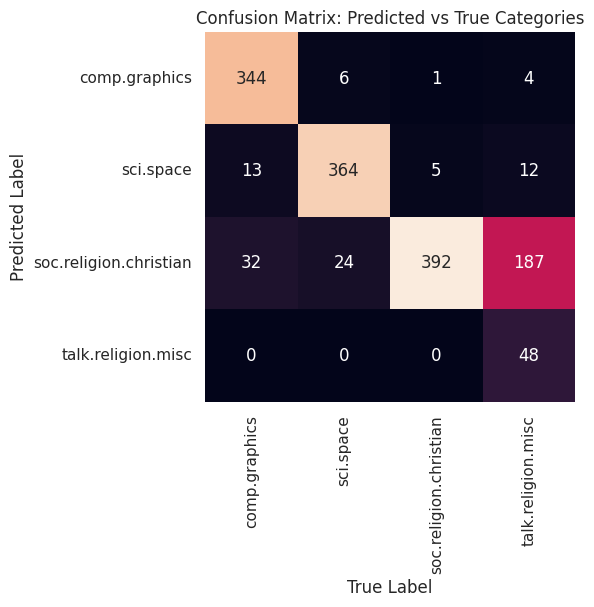

In [4]:
mat = confusion_matrix(test.target, labels)

sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=train.target_names, yticklabels=train.target_names)

plt.xlabel('True Label')
plt.ylabel('Predicted Label')
plt.title('Confusion Matrix: Predicted vs True Categories')
plt.show()

In [5]:
# Print a quick classification report
from sklearn.metrics import classification_report
print(classification_report(test.target, labels, target_names=test.target_names))

                        precision    recall  f1-score   support

         comp.graphics       0.97      0.88      0.92       389
             sci.space       0.92      0.92      0.92       394
soc.religion.christian       0.62      0.98      0.76       398
    talk.religion.misc       1.00      0.19      0.32       251

              accuracy                           0.80      1432
             macro avg       0.88      0.75      0.73      1432
          weighted avg       0.86      0.80      0.77      1432



**6. Testing with Custom Input**

This model can now be used to predict the category of any arbitrary string of text.

In [6]:
def predict_category(s, train=train, model=model):
    pred = model.predict([s])
    return train.target_names[pred[0]]

# Try a few examples
print(f"1. 'sending a payload to the ISS' -> {predict_category('sending a payload to the ISS')}")
print(f"2. 'discussing the nature of god' -> {predict_category('discussing the nature of god')}")
print(f"3. 'screen resolution and pixels' -> {predict_category('screen resolution and pixels')}")

1. 'sending a payload to the ISS' -> sci.space
2. 'discussing the nature of god' -> soc.religion.christian
3. 'screen resolution and pixels' -> comp.graphics


**Why use Naive Bayes for text?**

**Speed**: It is incredibly fast for both training and prediction.

**High Dimensions**: It handles the massive number of "features" (unique words) in text data very well.

**Baseline**: It provides a great "quick-and-dirty" baseline before trying more complex models like SVMs or Neural Networks.

### **Hyperparameter Tuning**


To take this a step further, we can look at how to improve the model. In Multinomial Naive Bayes, the most important hyperparameter is Alpha ($\alpha$), which controls Laplace smoothing.Smoothing is used to handle the "zero-probability problem"—when a word appears in the test data that was never seen in the training data. Without smoothing, the model would assign a probability of zero to that entire document, making it impossible to classify.

**1. Understanding the Alpha Parameter**

**High Alpha**: More smoothing. It makes the model less sensitive to specific word counts, which can prevent overfitting but might "wash out" important patterns.

**Low Alpha**: Less smoothing. The model trusts the training data counts more strictly.

**2. Tuning with GridSearch**

Instead of guessing the best Alpha, we can use GridSearchCV to test a range of values and see which one yields the highest accuracy.

In [7]:
from sklearn.model_selection import GridSearchCV

# Define the pipeline again
pipeline = make_pipeline(TfidfVectorizer(), MultinomialNB())

# Define the parameters to test
# 'multinomialnb__alpha' follows the naming convention: [lowercase_model_name]__[parameter]
param_grid = {
    'tfidfvectorizer__ngram_range': [(1, 1), (1, 2)], # Test single words vs word pairs
    'multinomialnb__alpha': [0.01, 0.1, 0.5, 1.0, 2.0]
}

# Set up the GridSearch
grid = GridSearchCV(pipeline, param_grid, cv=5)
grid.fit(train.data, train.target)

print(f"Best parameters: {grid.best_params_}")
print(f"Best cross-validation score: {grid.best_score_:.3f}")

Best parameters: {'multinomialnb__alpha': 0.01, 'tfidfvectorizer__ngram_range': (1, 2)}
Best cross-validation score: 0.965


**3. Evaluating the "Optimized" Model**

Now we apply the best version of our model to the test set to see the final performance.

In [8]:
# Use the best estimator found by GridSearch
best_model = grid.best_estimator_
final_labels = best_model.predict(test.data)

# Print a quick classification report
from sklearn.metrics import classification_report
print(classification_report(test.target, final_labels, target_names=test.target_names))

                        precision    recall  f1-score   support

         comp.graphics       0.93      0.95      0.94       389
             sci.space       0.95      0.94      0.95       394
soc.religion.christian       0.88      0.97      0.92       398
    talk.religion.misc       0.95      0.78      0.86       251

              accuracy                           0.92      1432
             macro avg       0.93      0.91      0.92      1432
          weighted avg       0.93      0.92      0.92      1432



**Summary of Strengths**

Even after tuning, the core logic remains the same. Naive Bayes performs exceptionally well in high-dimensional spaces because, as the number of features (words) grows, the "clusters" of data points tend to naturally separate further apart in that space.

Source
https://jakevdp.github.io/PythonDataScienceHandbook/05.05-naive-bayes.html